In [1]:
import sys
print(sys.executable)

/Users/lucasprado/Documents/Faculdade - UTFPR/TCC/.venv/bin/python


Imports

In [3]:
import csv
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

Vídeo selecionado

In [4]:
VIDEO_NAME = "video_test.mp4"

VIDEO_PATH = "../videos/" + VIDEO_NAME

CSV_PATH = "../results/" + VIDEO_NAME.replace(".mp4", ".csv")
FLUXO_CSV_PATH = "../results/" + VIDEO_NAME.replace(".mp4", "_fluxo.csv")
TIPOS_CSV_PATH = "../results/" + VIDEO_NAME.replace(".mp4", "_tipos.csv")

FLUXO_GRAPH_PATH = "../graphs/" + VIDEO_NAME.replace(".mp4", "_fluxo.png")
TIPOS_GRAPH_PATH = "../graphs/" + VIDEO_NAME.replace(".mp4", "_tipos.png")
INTERVALOS_GRAPH_PATH = "../graphs/" + VIDEO_NAME.replace(".mp4", "_intervalos.png")

MODEL_PATH = "../models/yolo11n.pt"

Teste YOLOv11 com video

In [5]:
model = YOLO(MODEL_PATH)
model.to("mps")

video = cv2.VideoCapture(VIDEO_PATH)
fps = video.get(cv2.CAP_PROP_FPS)
video.release()

results = model.track(
    VIDEO_PATH,
    classes=[2,3,5,7],
    conf=0.6,
    save=False,
    stream=True
)


In [6]:
total = 0
frame_num = 0
intervalo_segundos = 2

ids_unicos = set()
ids_por_tipo = {}
primeiro_tempo_por_id = {}
fluxo_por_intervalo = {}
dados = []

for r in results:
    frame_num += 1
    tempo = frame_num / fps
    total += len(r.boxes)

    if r.boxes.id is not None:
        for cls, obj_id in zip(r.boxes.cls.tolist(), r.boxes.id.tolist()):
            obj_id = int(obj_id)
            nome = r.names[int(cls)]

            ids_unicos.add(obj_id)

            if nome not in ids_por_tipo:
                ids_por_tipo[nome] = set()
            ids_por_tipo[nome].add(obj_id)

            if obj_id not in primeiro_tempo_por_id:
                primeiro_tempo_por_id[obj_id] = tempo
                inicio = int((tempo // intervalo_segundos) * intervalo_segundos)
                if inicio not in fluxo_por_intervalo:
                    fluxo_por_intervalo[inicio] = 0
                fluxo_por_intervalo[inicio] += 1

    dados.append([tempo, len(ids_unicos)])

print("Total de detecções de veículos:", total)
print("Veículos únicos:", len(ids_unicos))


video 1/1 (frame 1/288) /Users/lucasprado/Documents/Faculdade - UTFPR/TCC/notebooks/../videos/video_test.mp4: 640x384 (no detections), 161.3ms
video 1/1 (frame 2/288) /Users/lucasprado/Documents/Faculdade - UTFPR/TCC/notebooks/../videos/video_test.mp4: 640x384 (no detections), 21.4ms
video 1/1 (frame 3/288) /Users/lucasprado/Documents/Faculdade - UTFPR/TCC/notebooks/../videos/video_test.mp4: 640x384 (no detections), 20.7ms
video 1/1 (frame 4/288) /Users/lucasprado/Documents/Faculdade - UTFPR/TCC/notebooks/../videos/video_test.mp4: 640x384 (no detections), 23.1ms
video 1/1 (frame 5/288) /Users/lucasprado/Documents/Faculdade - UTFPR/TCC/notebooks/../videos/video_test.mp4: 640x384 (no detections), 19.9ms
video 1/1 (frame 6/288) /Users/lucasprado/Documents/Faculdade - UTFPR/TCC/notebooks/../videos/video_test.mp4: 640x384 1 car, 18.3ms
video 1/1 (frame 7/288) /Users/lucasprado/Documents/Faculdade - UTFPR/TCC/notebooks/../videos/video_test.mp4: 640x384 1 car, 20.7ms
video 1/1 (frame 8/288) 

In [15]:
for nome, conjunto in ids_por_tipo.items():
    print(nome, len(conjunto))

duracao_video = frame_num / fps
veiculos_por_minuto = len(ids_unicos) / (duracao_video / 60)

print("Duração do vídeo (s):", duracao_video)
print("Fluxo médio (veículos/min):", veiculos_por_minuto)

tempos_ordenados = sorted(primeiro_tempo_por_id.values())
intervalos = []

for i in range(1, len(tempos_ordenados)):
    intervalos.append(tempos_ordenados[i] - tempos_ordenados[i - 1])

if len(intervalos) > 0:
    tempo_medio = sum(intervalos) / len(intervalos)
    print("Tempo médio entre veículos:", tempo_medio)

if len(fluxo_por_intervalo) > 0:
    pico_inicio = max(fluxo_por_intervalo, key=fluxo_por_intervalo.get)
    pico_fim = pico_inicio + intervalo_segundos
    pico_valor = fluxo_por_intervalo[pico_inicio]
    print("Pico de tráfego entre", pico_inicio, "e", pico_fim, "segundos")
    print("Veículos no pico:", pico_valor)

car 12
truck 1
Duração do vídeo (s): 11.886875
Fluxo médio (veículos/min): 65.6185919343814
Tempo médio entre veículos: 0.806361111111111
Pico de tráfego entre 4 e 6 segundos
Veículos no pico: 4


In [16]:
with open(CSV_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["tempo_segundos", "veiculos_acumulados"])
    writer.writerows(dados)

with open(FLUXO_CSV_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["inicio_segundos", "fim_segundos", "veiculos_novos"])
    for inicio in sorted(fluxo_por_intervalo.keys()):
        writer.writerow([inicio, inicio + intervalo_segundos, fluxo_por_intervalo[inicio]])

with open(TIPOS_CSV_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["tipo", "quantidade"])
    for nome, conjunto in ids_por_tipo.items():
        writer.writerow([nome, len(conjunto)])

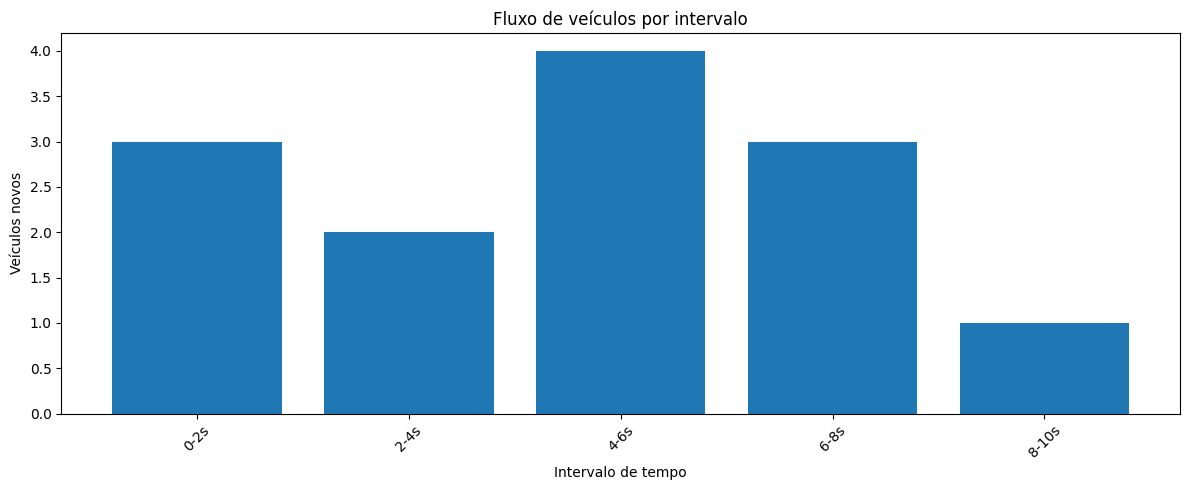

In [17]:
intervalos_x = []
valores_y = []

for inicio in sorted(fluxo_por_intervalo.keys()):
    intervalos_x.append(f"{inicio}-{inicio + intervalo_segundos}s")
    valores_y.append(fluxo_por_intervalo[inicio])

plt.figure(figsize=(12, 5))
plt.bar(intervalos_x, valores_y)
plt.xlabel("Intervalo de tempo")
plt.ylabel("Veículos novos")
plt.title("Fluxo de veículos por intervalo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FLUXO_GRAPH_PATH)
plt.show()

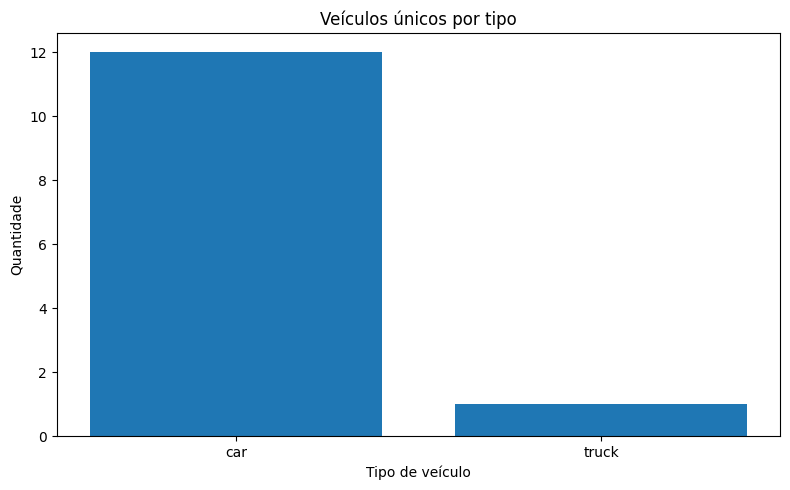

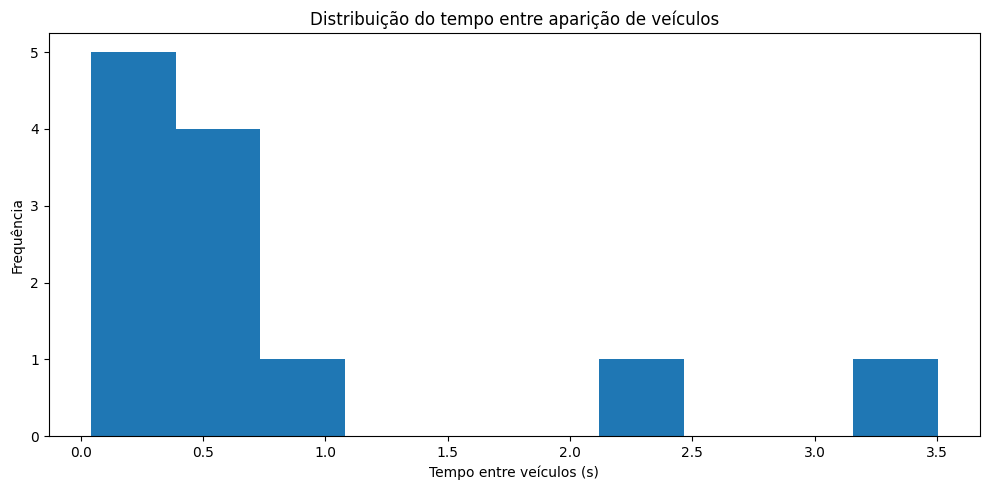

In [18]:
tipos = []
quantidades = []

for nome, conjunto in ids_por_tipo.items():
    tipos.append(nome)
    quantidades.append(len(conjunto))

plt.figure(figsize=(8, 5))
plt.bar(tipos, quantidades)
plt.xlabel("Tipo de veículo")
plt.ylabel("Quantidade")
plt.title("Veículos únicos por tipo")
plt.tight_layout()
plt.savefig(TIPOS_GRAPH_PATH)
plt.show()

if len(intervalos) > 0:
    plt.figure(figsize=(10, 5))
    plt.hist(intervalos, bins=10)
    plt.xlabel("Tempo entre veículos (s)")
    plt.ylabel("Frequência")
    plt.title("Distribuição do tempo entre aparição de veículos")
    plt.tight_layout()
    plt.savefig(INTERVALOS_GRAPH_PATH)
    plt.show()